In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.pairs.data import download_prices, compute_log_returns
from src.pairs.universe import UNIVERSE
from src.pairs.cointegration import (
    all_pairs_coint,            # was test_all_pairs
    bonferroni_threshold,
    benjamini_hochberg,
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [2]:
prices = download_prices()
print(f"Loaded {prices.shape[0]} days × {prices.shape[1]} tickers")
prices.head()

Loaded 1258 days × 31 tickers


,AAPL,MSFT,GOOGL,META,AMZN,NVDA,AMD,INTC,TSM,AVGO,...,CVX,COP,SLB,T,VZ,DIS,NFLX,BA,CAT,GE
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-02,72.333878,151.829575,67.873024,208.146561,94.900497,5.970754,49.099998,53.666466,53.628571,27.677496,...,91.182587,51.773109,34.669903,18.787169,41.978821,144.790268,32.980999,331.348572,132.312897,57.747486
2020-01-03,71.630623,149.939011,67.517967,207.045197,93.748497,5.875187,48.599998,53.013718,51.860001,26.973518,...,90.867188,51.962944,35.006504,18.883856,41.531868,143.129379,32.590000,330.791901,130.475800,57.941116
2020-01-06,72.201424,150.326599,69.317589,210.944626,95.143997,5.899825,48.389999,52.863762,51.261551,26.933163,...,90.559319,52.579849,35.230904,18.903196,41.442482,142.298950,33.583000,331.766083,130.387939,58.764011
2020-01-07,71.861839,148.955933,69.183701,211.401047,95.343002,5.971253,48.250000,51.981674,52.092239,26.840448,...,89.402924,52.579849,35.049667,18.975714,40.981773,142.347778,33.075001,335.285156,128.665131,58.328350
2020-01-08,73.017845,151.328568,69.676132,213.544220,94.598503,5.982452,47.830002,52.016956,52.476322,26.505629,...,88.381683,51.361847,34.013962,19.033731,41.057423,142.054688,33.925999,329.410095,129.807800,57.795902


In [3]:
results = all_pairs_coint(prices)
print(f"Tested {len(results)} pairs")
print(f"Number with raw p < 0.05: {(results['p_value'] < 0.05).sum()}")
print(f"Number with raw p < 0.01: {(results['p_value'] < 0.01).sum()}")
results.head(20)

Tested 465 pairs
Number with raw p < 0.05: 51
Number with raw p < 0.01: 30


,y,x,p_value,t_stat,crit_1pct,crit_5pct,crit_10pct,n_obs
0,GS,WFC,0.002038,-4.362987,-3.905174,-3.340995,-3.047826,1258
1,BA,KO,0.002052,-4.361195,-3.905174,-3.340995,-3.047826,1258
2,AAPL,PG,0.002065,-4.359411,-3.905174,-3.340995,-3.047826,1258
3,PEP,SLB,0.002278,-4.332422,-3.905174,-3.340995,-3.047826,1258
4,BA,CVX,0.002278,-4.332359,-3.905174,-3.340995,-3.047826,1258
5,BA,DIS,0.002410,-4.316883,-3.905174,-3.340995,-3.047826,1258
6,BA,COP,0.002649,-4.290476,-3.905174,-3.340995,-3.047826,1258
7,BA,XOM,0.002694,-4.285843,-3.905174,-3.340995,-3.047826,1258
8,BA,COST,0.002726,-4.282499,-3.905174,-3.340995,-3.047826,1258
9,BA,PG,0.002768,-4.278172,-3.905174,-3.340995,-3.047826,1258


In [6]:
n_tests = len(results)
bonferroni_thr = bonferroni_threshold(n_tests, alpha=0.05)
results["p_adj_bh"] = benjamini_hochberg(results["p_value"])

print(f"Total tests: {n_tests}")
print(f"Bonferroni threshold (alpha=0.05): {bonferroni_thr:.5f}")
print()
print(f"Pairs passing raw p<0.05:         {(results['p_value'] < 0.05).sum()}")
print(f"Expected by chance at p<0.05:     {0.05 * n_tests:.1f}")
print()
print(f"Pairs passing Bonferroni:         {(results['p_value'] < bonferroni_thr).sum()}")
print(f"Pairs passing BH FDR=0.05:        {(results['p_adj_bh'] < 0.05).sum()}")

Total tests: 465
Bonferroni threshold (alpha=0.05): 0.00011

Pairs passing raw p<0.05:         51
Expected by chance at p<0.05:     23.2

Pairs passing Bonferroni:         0
Pairs passing BH FDR=0.05:        0


In [8]:
strong_pairs = results[results["p_value"] < bonferroni_thr].copy()
strong_pairs = strong_pairs.sort_values("p_value")
print(f"Pairs significant after Bonferroni correction ({len(strong_pairs)}):")
strong_pairs[["y", "x", "p_value", "p_adj_bh", "t_stat", "n_obs"]]

Pairs significant after Bonferroni correction (0):


,y,x,p_value,p_adj_bh,t_stat,n_obs


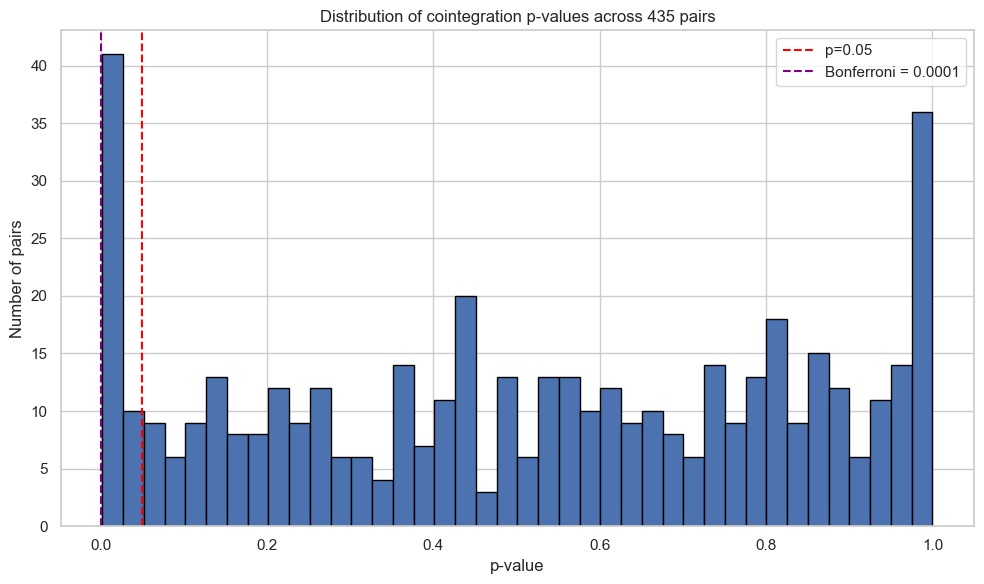

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(results["p_value"].dropna(), bins=40, edgecolor="black")
ax.axvline(0.05, color="red", linestyle="--", label="p=0.05")
ax.axvline(bonferroni_thr, color="purple", linestyle="--",
           label=f"Bonferroni = {bonferroni_thr:.4f}")
ax.set_xlabel("p-value")
ax.set_ylabel("Number of pairs")
ax.set_title("Distribution of cointegration p-values across 435 pairs")
ax.legend()
plt.tight_layout()
plt.show()

In [12]:
# Industry groupings, defined upfront to avoid look-ahead bias.
INDUSTRIES = {
    "mega_tech":      ["AAPL", "MSFT", "GOOGL", "META", "AMZN"],
    "semiconductors": ["NVDA", "AMD", "INTC", "TSM", "AVGO"],
    "banks":          ["JPM", "BAC", "WFC", "C", "GS"],
    "consumer":       ["KO", "PEP", "PG", "WMT", "COST"],
    "energy":         ["XOM", "CVX", "COP", "SLB"],
    "telecom_media":  ["T", "VZ", "DIS", "NFLX"],
    "industrials":    ["BA", "CAT", "GE"],
}

# Build the set of within-industry pairs (alphabetically ordered).
from itertools import combinations
within_industry_pairs = set()
for industry, tickers in INDUSTRIES.items():
    for a, b in combinations(sorted(tickers), 2):
        within_industry_pairs.add((a, b))

print(f"Within-industry pairs to test: {len(within_industry_pairs)}")
print(f"(vs {len(results)} unrestricted tests)")

# Filter the existing results to these pairs.
within = results[results.apply(
    lambda row: (row["y"], row["x"]) in within_industry_pairs, axis=1
)].copy()

print(f"\nWithin-industry results: {len(within)}")
print(f"Bonferroni threshold for {len(within)} tests at alpha=0.05: "
      f"{0.05 / len(within):.5f}")

# Recompute multiple-testing corrections on the smaller set.
within["p_adj_bh"] = benjamini_hochberg(within["p_value"])
within = within.sort_values("p_value").reset_index(drop=True)

print("\nTop 15 within-industry pairs:")
print(within.head(15)[["y", "x", "p_value", "p_adj_bh", "n_obs"]])

Within-industry pairs to test: 55
(vs 465 unrestricted tests)

Within-industry results: 55
Bonferroni threshold for 55 tests at alpha=0.05: 0.00091

Top 15 within-industry pairs:
       y     x   p_value  p_adj_bh  n_obs
0     GS   WFC  0.002038  0.059413   1258
1     BA    GE  0.002983  0.059413   1258
2     BA   CAT  0.003241  0.059413   1258
3      C    GS  0.044089  0.606228   1258
4   COST    PG  0.067492  0.628865   1258
5      C   JPM  0.068603  0.628865   1258
6   AMZN  META  0.088584  0.640744   1258
7   AVGO  NVDA  0.093199  0.640744   1258
8    COP   CVX  0.116362  0.690650   1258
9    COP   SLB  0.125640  0.690650   1258
10    GS   JPM  0.149975  0.690650   1258
11    KO    PG  0.150687  0.690650   1258
12   CAT    GE  0.182059  0.770249   1258
13   CVX   SLB  0.203911  0.801079   1258
14   BAC     C  0.268025  0.910049   1258


In [13]:
# Final candidate pairs for Day 3 analysis (Kalman filter + backtest).
#
# Selected as a mix of:
#   (a) strongest static-cointegration signal (top 3 by p-value), and
#   (b) canonical "should cointegrate" same-industry pairs that
#       static OLS missed -- these test whether dynamic hedge ratios
#       reveal relationships that static methods cannot.
#
# This list is fixed at the end of Day 2 to avoid choosing pairs
# in retrospect after seeing backtest results.
CANDIDATE_PAIRS = [
    # Strong static signal
    ("GS",   "WFC"),
    ("BA",   "GE"),
    ("BA",   "CAT"),
    # Same-industry, weak static signal (the Kalman-filter test cases)
    ("C",    "JPM"),
    ("KO",   "PG"),
    ("AVGO", "NVDA"),
    ("COST", "PG"),
    ("CVX",  "SLB"),
]

# Pull these out of the full results table for record-keeping.
candidate_results = within[
    within.apply(lambda row: (row["y"], row["x"]) in CANDIDATE_PAIRS, axis=1)
].copy()

print(f"Candidate pairs for Day 3 ({len(candidate_results)}):")
print(candidate_results[["y", "x", "p_value", "p_adj_bh", "n_obs"]])

# Save for Day 3.
output_path = project_root / "data" / "processed" / "candidate_pairs.parquet"
candidate_results.to_parquet(output_path)
print(f"\nSaved to {output_path}")

Candidate pairs for Day 3 (8):
       y     x   p_value  p_adj_bh  n_obs
0     GS   WFC  0.002038  0.059413   1258
1     BA    GE  0.002983  0.059413   1258
2     BA   CAT  0.003241  0.059413   1258
4   COST    PG  0.067492  0.628865   1258
5      C   JPM  0.068603  0.628865   1258
7   AVGO  NVDA  0.093199  0.640744   1258
11    KO    PG  0.150687  0.690650   1258
13   CVX   SLB  0.203911  0.801079   1258

Saved to /home/vaibhav/Projects/pairs-trading/data/processed/candidate_pairs.parquet


In [11]:
print("Total pairs tested:", len(results))
print()
print("p-value distribution:")
print(f"  min:    {results['p_value'].min():.6f}")
print(f"  median: {results['p_value'].median():.4f}")
print(f"  max:    {results['p_value'].max():.4f}")
print()
print(f"Bonferroni threshold (alpha=0.05): {bonferroni_thr:.6f}")
print()
print("Pairs by significance level:")
print(f"  p < Bonferroni ({bonferroni_thr:.5f}): {(results['p_value'] < bonferroni_thr).sum()}")
print(f"  p < 0.001:                            {(results['p_value'] < 0.001).sum()}")
print(f"  p < 0.01:                             {(results['p_value'] < 0.01).sum()}")
print(f"  p < 0.05:                             {(results['p_value'] < 0.05).sum()}")
print(f"  p < 0.10:                             {(results['p_value'] < 0.10).sum()}")
print()
print("Top 10 pairs by p-value:")
print(results.head(10)[["y", "x", "p_value", "n_obs"]])

Total pairs tested: 465

p-value distribution:
  min:    0.002038
  median: 0.5360
  max:    1.0000

Bonferroni threshold (alpha=0.05): 0.000108

Pairs by significance level:
  p < Bonferroni (0.00011): 0
  p < 0.001:                            0
  p < 0.01:                             30
  p < 0.05:                             51
  p < 0.10:                             66

Top 10 pairs by p-value:
      y     x   p_value  n_obs
0    GS   WFC  0.002038   1258
1    BA    KO  0.002052   1258
2  AAPL    PG  0.002065   1258
3   PEP   SLB  0.002278   1258
4    BA   CVX  0.002278   1258
5    BA   DIS  0.002410   1258
6    BA   COP  0.002649   1258
7    BA   XOM  0.002694   1258
8    BA  COST  0.002726   1258
9    BA    PG  0.002768   1258


In [10]:
top_pair = strong_pairs.iloc[0]
y_t, x_t = top_pair["y"], top_pair["x"]
print(f"Visualizing top pair: {y_t} vs {x_t} (p={top_pair['p_value']:.6f})")

# Re-run the regression to get the hedge ratio.
from statsmodels.api import OLS, add_constant
pair = prices[[y_t, x_t]].dropna()
model = OLS(pair[y_t], add_constant(pair[x_t])).fit()
alpha, beta = model.params["const"], model.params[x_t]
spread = pair[y_t] - beta * pair[x_t] - alpha

print(f"Hedge ratio (beta): {beta:.4f}")
print(f"Intercept (alpha):  {alpha:.4f}")
print(f"Spread mean:        {spread.mean():.4f}")
print(f"Spread std:         {spread.std():.4f}")

# Plot the spread with mean and ±2σ bands.
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(spread, label=f"Spread = {y_t} - {beta:.3f}·{x_t} - {alpha:.3f}")
ax.axhline(spread.mean(), color="black", linestyle="-", linewidth=0.5)
ax.axhline(spread.mean() + 2*spread.std(), color="red", linestyle="--", label="+2σ")
ax.axhline(spread.mean() - 2*spread.std(), color="red", linestyle="--", label="-2σ")
ax.set_title(f"Spread of {y_t} - {beta:.3f}·{x_t}")
ax.set_ylabel("Spread")
ax.legend()
plt.tight_layout()
plt.show()

IndexError: single positional indexer is out-of-bounds

In [ ]:
output_path = project_root / "data" / "processed" / "cointegration_results.parquet"
output_path.parent.mkdir(parents=True, exist_ok=True)
results.to_parquet(output_path)
print(f"Saved to {output_path}")